4) Recurrent neural network (RNN) Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,LSTM,Dense,Dropout
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df = pd.read_csv("goog.csv")
df

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400
...,...,...,...,...,...,...
56,3/13/2017,844.000000,848.684998,843.250000,845.539978,1149500
57,3/14/2017,843.640015,847.239990,840.799988,845.619995,779900
58,3/15/2017,847.590027,848.630005,840.770020,847.200012,1379600
59,3/16/2017,849.030029,850.849976,846.130005,848.780029,970400


In [3]:
data = df[['Close']].values.reshape(-1,1)

In [4]:
mm = MinMaxScaler()
data = mm.fit_transform(data)

In [5]:
split = int(len(data)*0.8)
train = data[:split]
test = data[split:]

In [6]:
def create_dataset(data,step=4):
    x,y =[],[]
    for i in range (len(data)-step):
        x.append(data[i:i+step])
        y.append(data[i])
    return np.array(x),np.array(y)

xtrain , ytrain = create_dataset(train)
xtest , ytest = create_dataset(test)

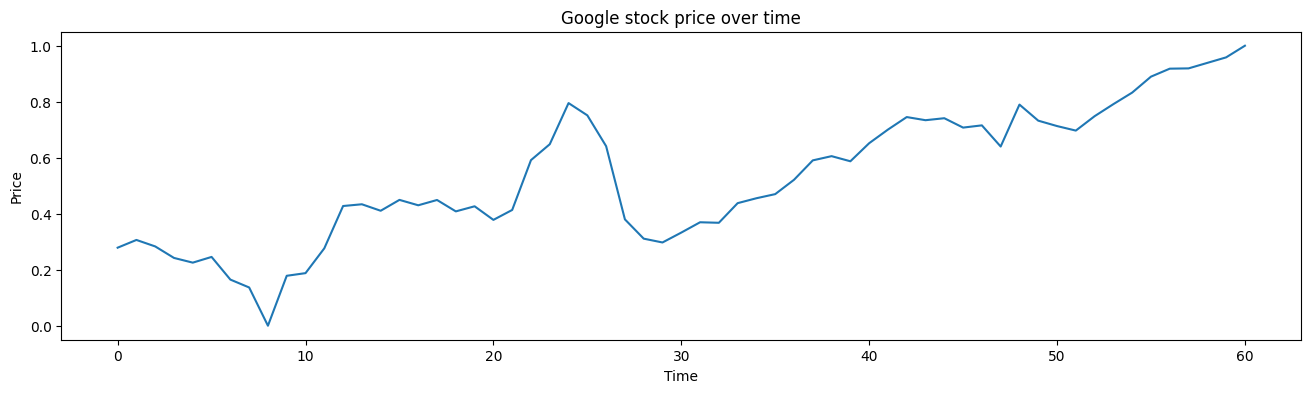

In [7]:
plt.figure(figsize=(16,4))
plt.plot(data)
plt.title("Google stock price over time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [8]:
model = Sequential()
model.add(SimpleRNN(64,return_sequences=True,input_shape=(xtrain.shape[1],1)))
model.add(Dropout(0.2))
model.add(SimpleRNN(32))
model.add(Dropout(0.2))
model.add(Dense(1))

C:\Users\Aditi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer ='adam',loss='mean_squared_error')

In [10]:
history = model.fit(xtrain,ytrain,epochs=30)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.9838
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2092
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1030
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2862
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2001
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2065
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0731
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0754
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0798
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0710
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0966
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0592
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0495
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0613
Epoch 15/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0407
Epoch 16/30
2/2 ━━━━━━━━━━━━━━━━━━

In [11]:
ypred = model.predict(xtest)
ypred = mm.inverse_transform(ypred)
ytest = mm.inverse_transform(ytest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step


Text(0, 0.5, 'Price')

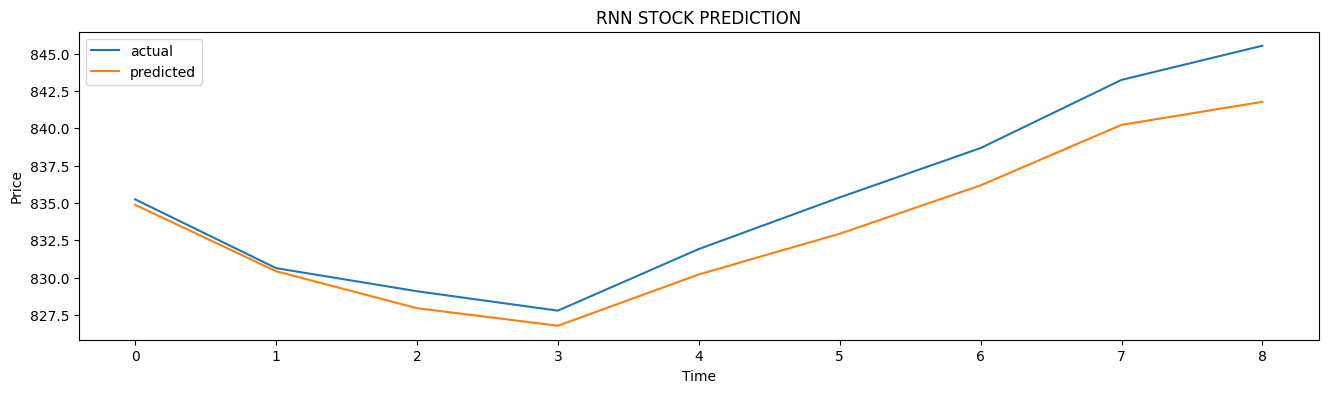

In [12]:
plt.figure(figsize=(16,4))
plt.plot(ytest,label='actual')
plt.plot(ypred,label='predicted')
plt.legend()
plt.title("RNN STOCK PREDICTION")
plt.xlabel("Time")
plt.ylabel("Price")

In [13]:
print(np.sqrt(mean_squared_error(ytest,ypred)))
print(r2_score(ytest,ypred))
ytrain_pred = model.predict(xtrain)
print(np.sqrt(mean_squared_error(ytrain,ytrain_pred)))
print(r2_score(ytrain,ytrain_pred))

2.129336645498189
0.8675221692645092
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step 
0.020712728646322794
0.9871927938653461
